In [1]:
import sys
import datetime as dt
import pandas as pd
from pathlib import Path

sys.path.append(str(Path.cwd().parent)) 

from data.daily_data_loader import get_asset_index_prices, get_wmco_prices
from data.resampled_data_loader import get_resampled_quotes

start_date = dt.date(2010, 1, 1)
end_date = dt.date(2025, 12, 31)

ccys = ['USD', 'EUR', 'JPY', 'GBP', 'CHF', 'NOK', 'SEK', 'AUD', 'NZD', 'CAD']
equity_close_dict = get_asset_index_prices('equity', ccys, start_date, end_date)
bond_close_dict = get_asset_index_prices('bond', ccys, start_date, end_date)
traded_instruments = [
    "AUDUSD",
    "EURUSD",
    "GBPUSD",
    "EURGBP",
    "EURJPY",
    "USDJPY",
    "USDCHF",
    "EURCHF",
    "USDCAD",
    "USDNOK",
    "USDSEK",
    "EURNOK",
    "EURSEK",
    "NZDUSD",
]
freq = pd.Timedelta(minutes=15)
fx_price_dict = get_resampled_quotes(traded_instruments, start_date, end_date, freq)
#fx_price_dict = get_wmco_prices(traded_instruments, start_date, end_date)

In [15]:
import importlib
import strategy.AMEN_strategy as am

importlib.reload(am)
from strategy.AMEN_strategy import AmenStrategy

strategy = AmenStrategy(traded_instruments, fx_price_dict, equity_close_dict, bond_close_dict,
                        {
                            "look_back_months" : 60,
                            "use_all_countries" : False,
                            "entry_time_offset_from_month_end" : pd.Timedelta(minutes=135),
                            "exit_time_offset_from_month_end" : pd.Timedelta(minutes=-15),
                            "prediction_zscore_threshold" : 0.5,
                            "prediction_rank_threshold" : 1.0,
                        })


In [16]:
signals = strategy.generate_signals()
position_times = strategy.create_monthly_asset_returns(pd.Timedelta(hours=1)).index

In [17]:
from trading.aggressive_trader import AggressiveTrader
from analytics.performance_report import PerformanceReport

trader = AggressiveTrader(traded_instruments, fx_price_dict, signals)

report = PerformanceReport(traded_instruments, trader)

report.generate_performance_report()

,Sharpe_Net,Sharpe_Gross,AvgTradesPerDay,MaxDrawdown,WorstDayPnL,AvgNetPnLPerTrade,AvgGrossPnLPerTrade,AvgPosDur,MedPosDur,Q10PosDur,Q90PosDur
AUDUSD,0.077306,0.158544,0.031336,-0.031568,-0.008569,0.000058,0.000119,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00
EURUSD,0.488741,0.509194,0.029758,-0.010562,-0.005608,0.000354,0.00037,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00
GBPUSD,0.455406,0.494698,0.02526,-0.014514,-0.005073,0.000379,0.000413,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00
EURGBP,0.454793,0.517768,0.029105,-0.012003,-0.006429,0.000307,0.000352,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00
EURJPY,0.477151,0.518587,0.02686,-0.020873,-0.008723,0.000381,0.000415,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00
USDJPY,0.331819,0.365685,0.027735,-0.015548,-0.006763,0.000191,0.00021,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00
USDCHF,-0.055251,0.017995,0.031997,-0.046787,-0.007938,-0.000037,0.000012,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00
EURCHF,0.77683,0.848435,0.030796,-0.00897,-0.004586,0.000433,0.000485,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00
USDCAD,-0.084618,-0.034258,0.029105,-0.039841,-0.007219,-0.000066,-0.000027,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00
USDNOK,-0.146694,0.020091,0.030647,-0.054243,-0.014011,-0.000134,0.000018,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00,0 days 02:00:00


<Axes: xlabel='timestamp'>

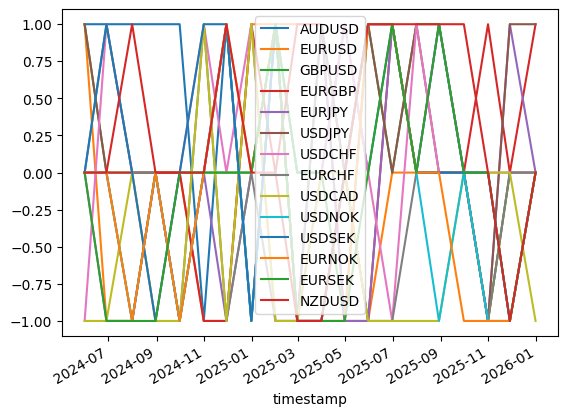

In [18]:
positions = pd.DataFrame(trader.generate_positions())
positions.loc[position_times[-20:]].plot()

<Axes: title={'center': 'GBPUSD Cumulative PnL'}, xlabel='Time', ylabel='Cumulative PnL'>

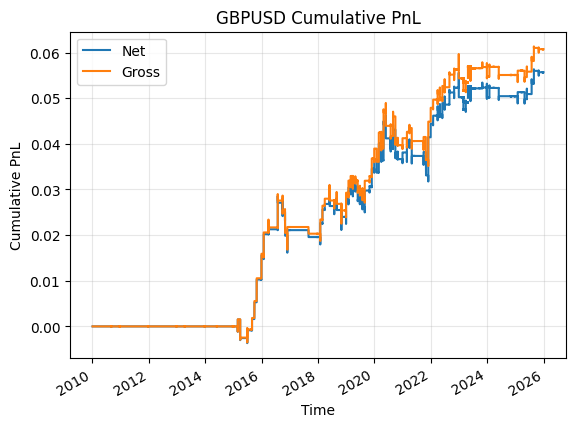

In [19]:
report.plot_cumulative_pnl('GBPUSD')

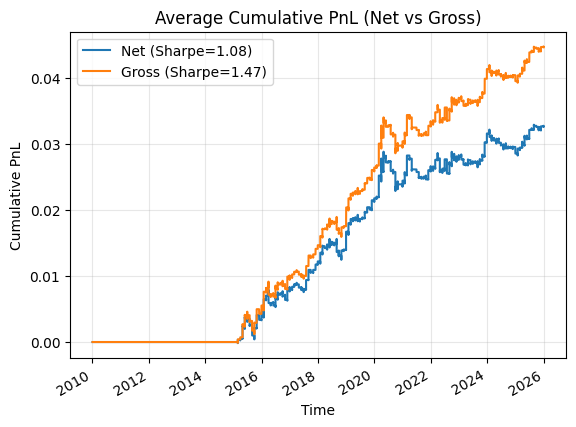

In [20]:
import numpy as np

freq_mult = pd.Timedelta(days=2) / freq

net_pnl_dict = trader.generate_net_pnl()
gross_pnl_dict = trader.generate_gross_pnl()

net_df = pd.DataFrame(net_pnl_dict).fillna(0.0)
gross_df = pd.DataFrame(gross_pnl_dict).fillna(0.0)

avg_net = net_df.mean(axis=1)
avg_gross = gross_df.mean(axis=1)

net_sharpe = np.sqrt(252 * freq_mult) * avg_net.mean() / avg_net.std() if avg_net.std() != 0 else np.nan
gross_sharpe = (
    np.sqrt(252 * freq_mult) * avg_gross.mean() / avg_gross.std() if avg_gross.std() != 0 else np.nan
)

ax = avg_net.cumsum().plot(label=f"Net (Sharpe={net_sharpe:.2f})")
avg_gross.cumsum().plot(ax=ax, label=f"Gross (Sharpe={gross_sharpe:.2f})")

ax.set_title("Average Cumulative PnL (Net vs Gross)")
ax.set_xlabel("Time")
ax.set_ylabel("Cumulative PnL")
ax.legend()
ax.grid(True, alpha=0.3)


In [14]:
from analytics.plot_daily_recap import plot_daily_recap

instrument = "GBPUSD"
date_range = (dt.date(2025, 9, 15), dt.date(2025, 10, 3))
close_price_df = fx_price_dict[instrument]
plot_daily_recap(instrument, date_range, close_price_df, strategy, trader)

In [ ]:
import pandas as pd

from analytics.hyperparam_optimizer import optimize_strategy_hyperparams
from strategy.AMEN_strategy import AmenStrategy

traded_instruments = ["EURUSD", "GBPUSD", "USDJPY"]

result = optimize_strategy_hyperparams(
    strategy_cls=AmenStrategy,
    strategy_kwargs={
        "traded_instruments": tuple(traded_instruments),
        "fx_price_dict": fx_price_dict,
        "equity_close_dict": equity_close_dict,
        "bond_close_dict": bond_close_dict,
    },
    instruments=traded_instruments,
    close_price_dict=fx_price_dict,  # what AggressiveTrader trades
    param_grid={
        "look_back_months": [24, 36, 60],
        "prediction_rank_threshold": [0.2, 1 / 3, 0.5],
        "prediction_zscore_threshold": [0.0, 0.5, 1.0],
        "use_all_countries": [True, False],
        "time_offset_from_month_end": [
            pd.Timedelta(days=0),
            pd.Timedelta(days=1),
        ],
    },
    metric="Sharpe_Net",
    log_path="src/systematic_trading/script/amen_hyperparam_trials.csv",
    checkpoint_every=10,
    resume=True,
)

print(result.metric_name)
print(result.best_metric_by_pair)
print(result.best_params_portfolio)
print(result.best_metric_portfolio)